### How to use the IGN elevation data ? (short tutorial for ... myself)

Download the data : https://geoservices.ign.fr/rgealti

The IGN provides access to two datasets, one with a 1-meter resolution and the other with a 5-meter resolution. I will use the 5-meter resolution dataset.
After downloading the data, you will have a folder with three subfolders:

- 1_DONNEES_LIVRAISON : contains the elevation of the downloaded datasets, divided into tiles. Each tile is an .asc file.

- 2_METADONNEES_LIVRAISON : contains metadata.

- 3_SUPPLEMENTS_LIVRAISON : contains a shapefile describing the tiles.

We will need to manipulate the shapefile and .asc files

In [31]:
%pip install rioxarray geopandas pyroj shapely

Note: you may need to restart the kernel to use updated packages.


-> I have a point (lon lat), which IGN slab gives me the associated elevation ?

First, we need to look in the shapefile which contains the geometry of each tile!

In [32]:
import rioxarray as xr
import os
import geopandas as gpd
import pyproj
from shapely.geometry import Point

In [33]:
#path to data
path = r"data/RGEALTI_44/3_SUPPLEMENTS_LIVRAISON_2023-01-00223/RGEALTI_MNT_5M_ASC_LAMB93_IGN69_D044"
file = "dalles.shp"

#open shapefile !
gdf = gpd.read_file(os.path.join(path, file))

This file uses a Lambert93 projection... we want to use the WGS84 system, let's convert WGS84 to Lambert93!

In [34]:
crs1 = "WGS84"
crs2 = pyproj.CRS(gdf.crs)

transformer = pyproj.Transformer.from_crs(crs1, crs2, always_xy=True)

In [35]:
#my point (in Nantes, Loire Atlantique 44)
lat = 47.220099278457994
lon = -1.5547499812958707

#coords (Lambert93) of my point
x, y = transformer.transform(lon, lat)

We have the coordinates of the point in the correct system, now we need to find out which file the elevation is in.

In [36]:
point = Point(x, y)

gdf[gdf.geometry.contains(point)]

,NOM_DALLE,SRC,SRV,DATE_DEBUT,DATE_FIN,PARTENAIRE,LITTO3D,PAS,CAPTEUR,Z_MIN,Z_MAX,NB_CORREL,NB_LIDAR_T,NB_LIDAR_B,NB_SMF,NB_RADAR,NB_NODATA,CGU,geometry
326,RGEALTI_FXX_0355_6690_MNT_LAMB93_IGN69,LAMB93,IGN69,2008-09-15,2010-10-12,NC,Oui,5,Multi,-1.9,37.4,566,999433,0,1,0,0,Licence IGN,"POLYGON ((355000 6685000, 355000 6690000, 3600..."


We get the name of the tile we're looking for! Now let's use the elevation data.

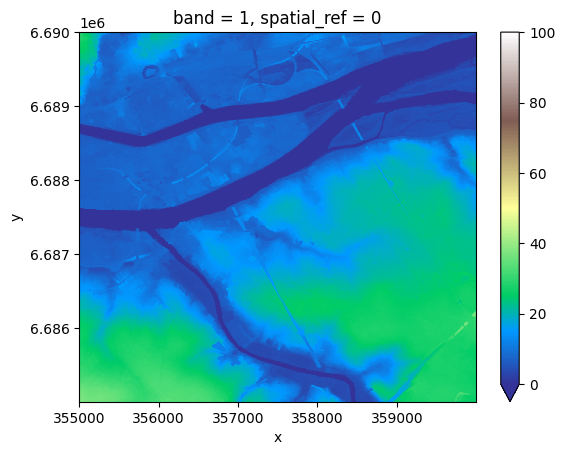

In [ ]:
tile_name = gdf[gdf.geometry.contains(point)].iloc[0].NOM_DALLE
tile_name = tile_name + ".asc"

#path to data
path = r"data/RGEALTI_44/1_DONNEES_LIVRAISON_2023-01-00223/RGEALTI_MNT_5M_ASC_LAMB93_IGN69_D044"

#open data
DS = xr.open_rasterio(os.path.join(path, tile_name))

#display (choose vmin and vmax carefully !)
DS.plot(cmap = "terrain", vmin = 0, vmax = 100)

It looks like this is the right tile! Now we just need to get the nearest altitude.

In [38]:
float(DS.sel(x = x, y = y, method = 'nearest'))

8.600000381469727

Success !

Tentative d'overlay (fix la projection TO DO)

In [39]:
%pip install rasterio matplotlib numpy folium

Note: you may need to restart the kernel to use updated packages.


BoundingBox(left=354997.5, bottom=6685002.5, right=359997.5, top=6690002.5)
[[47.17567097888911, -1.5576568126724155], [47.22318986848689, -1.4955043113423598]]



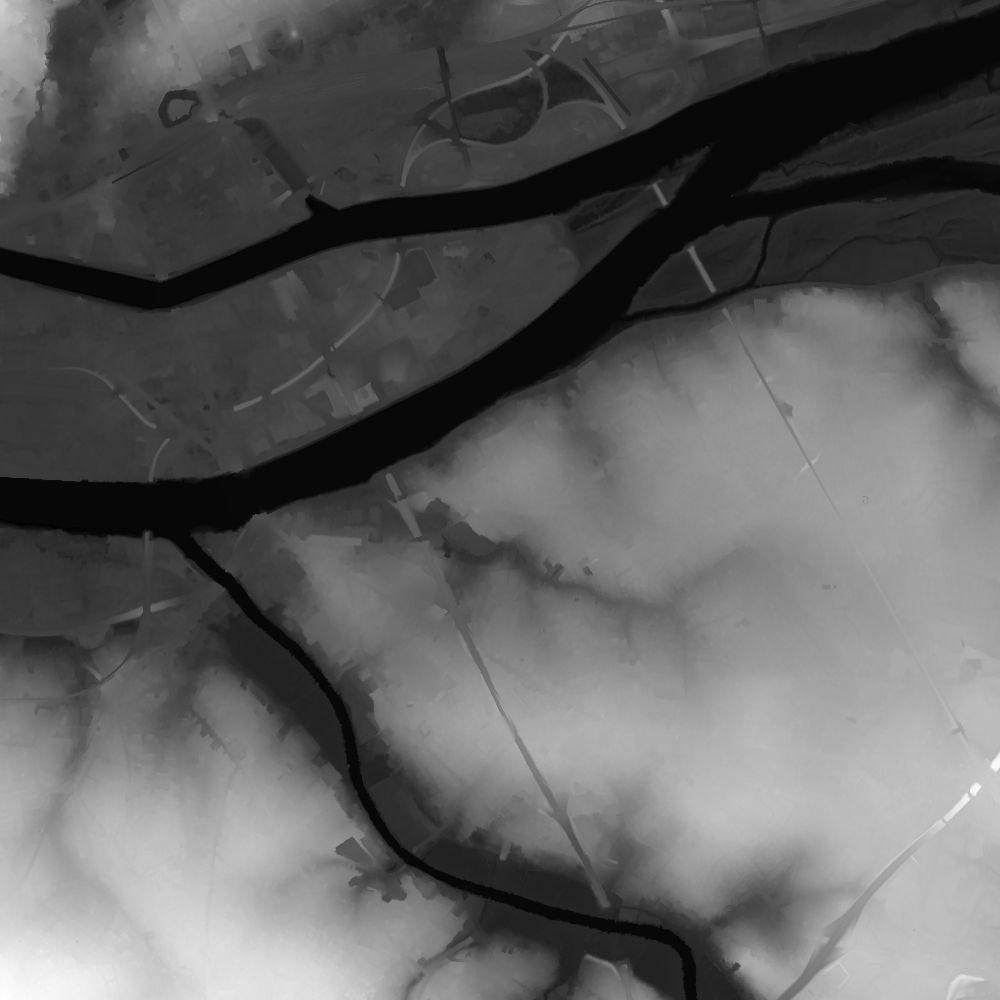

In [ ]:
import folium
from pyproj import Transformer
import rasterio
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

transformer = Transformer.from_crs(pyproj.CRS(gdf.crs), "WGS84", always_xy=True)

with rasterio.open(os.path.join(path, tile_name)) as src:
    array = src.read(1)
    bounds = src.bounds
    
    min_lon, min_lat = transformer.transform(bounds.left, bounds.bottom)
    max_lon, max_lat = transformer.transform(bounds.right, bounds.top)

    bbox_gps = [[min_lat, min_lon], [max_lat, max_lon]]

    norm_array = (array - np.nanmin(array)) / (np.nanmax(array) - np.nanmin(array))
    image_array = (255 * norm_array).astype(np.uint8)
    image = Image.fromarray(image_array)

m = folium.Map(location=[lat, lon], zoom_start=13)

# Ajout de l’image overlay
folium.raster_layers.ImageOverlay(
    name="Élévation",
    image=image,
    bounds = bbox_gps,
    mercator_project=True,
    opacity=0.6
).add_to(m)

print(bounds)
print(bbox_gps)

m
